In [16]:
# Importing all the necessary libraries for data processing and plotting

# !{sys.executable} -m pip install jinja2

import sys
import pandas as pd
import numpy as np
import openpyxl

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pycountry as pyc

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Optional: display settings
pd.set_option('display.max_columns', 8)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)


In [17]:
# Loading the total dataset.

dataf= pd.read_excel(r"C:\Users\dell\Desktop\CO2-dataset.xlsx")
print(dataf.head())

  Country Name Country Code      Indicator Name  Indicator Code  ...     2008  \
0        Aruba          ABW  CO2 emissions (kt)  EN.ATM.CO2E.KT  ...  2508.23   
1      Andorra          AND  CO2 emissions (kt)  EN.ATM.CO2E.KT  ...   539.05   
2  Afghanistan          AFG  CO2 emissions (kt)  EN.ATM.CO2E.KT  ...  4217.05   
3       Angola          AGO  CO2 emissions (kt)  EN.ATM.CO2E.KT  ... 27172.47   
4      Albania          ALB  CO2 emissions (kt)  EN.ATM.CO2E.KT  ...  4657.09   

      2009     2010     2011  
0  2522.90  2456.89  2438.55  
1   517.05   517.05   491.38  
2  6776.62  8470.77 12251.45  
3 29361.67 29743.04 29710.03  
4  4488.41  4415.07  4668.09  

[5 rows x 56 columns]


In [18]:
# Displaying the structure and basic info about data.

print(dataf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 56 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    248 non-null    object 
 1   Country Code    248 non-null    object 
 2   Indicator Name  248 non-null    object 
 3   Indicator Code  248 non-null    object 
 4   1960            178 non-null    float64
 5   1961            179 non-null    float64
 6   1962            180 non-null    float64
 7   1963            181 non-null    float64
 8   1964            186 non-null    float64
 9   1965            186 non-null    float64
 10  1966            186 non-null    float64
 11  1967            186 non-null    float64
 12  1968            185 non-null    float64
 13  1969            186 non-null    float64
 14  1970            188 non-null    float64
 15  1971            189 non-null    float64
 16  1972            192 non-null    float64
 17  1973            192 non-null    flo

In [19]:
# Checking for the null values in the data.

print(dataf.isnull().sum())

Country Name       0
Country Code       0
Indicator Name     0
Indicator Code     0
1960              70
                  ..
2007              16
2008              16
2009              16
2010              16
2011              16
Length: 56, dtype: int64


In [20]:
# Dropping null values and then confirming it.
df= dataf.dropna()
df.info()

print(df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 175 entries, 2 to 245
Data columns (total 56 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    175 non-null    object 
 1   Country Code    175 non-null    object 
 2   Indicator Name  175 non-null    object 
 3   Indicator Code  175 non-null    object 
 4   1960            175 non-null    float64
 5   1961            175 non-null    float64
 6   1962            175 non-null    float64
 7   1963            175 non-null    float64
 8   1964            175 non-null    float64
 9   1965            175 non-null    float64
 10  1966            175 non-null    float64
 11  1967            175 non-null    float64
 12  1968            175 non-null    float64
 13  1969            175 non-null    float64
 14  1970            175 non-null    float64
 15  1971            175 non-null    float64
 16  1972            175 non-null    float64
 17  1973            175 non-null    float64


In [21]:
# Keeping the copy of the raw data and Selecting the necessary columns from the data set.

rawdf= dataf[['Country Name', 'Country Code', '2000', '2011']]
df= rawdf.copy()
df

,Country Name,Country Code,2000,2011
0,Aruba,ABW,2321.21,2438.55
1,Andorra,AND,524.38,491.38
2,Afghanistan,AFG,781.07,12251.45
3,Angola,AGO,9541.53,29710.03
4,Albania,ALB,3021.61,4668.09
...,...,...,...,...
243,"Yemen, Rep.",YEM,14638.66,22295.36
244,South Africa,ZAF,368610.51,477241.72
245,"Congo, Dem. Rep.",COD,1646.48,3424.98
246,Zambia,ZMB,1822.50,3047.28


In [22]:
# Filtering out unncecssary rows from the data. (Selecting COUNTRIES only.)
import pycountry as pyc

valid_codes = {c.alpha_3 for c in pyc.countries}
df= df[df['Country Code'].isin(valid_codes)]

# Converting units from kilotones to megatones for better readability.

df= df[['Country Name', '2000', '2011']]
df['Country']= df['Country Name']
df['2000_Mt']= df['2000']/1000
df['2011_Mt']= df['2011']/1000

df= df[['Country', '2000_Mt', '2011_Mt']]

# Dropping rows with null values and reseting the indexes of the data,
# in order to avoid further confusion in the calculation process.

df.isnull().sum()
df= df.dropna()

df.reset_index(drop= True, inplace= True)

import numpy as np

# 1. Permanently KEEP only rows where '2000_Mt' is greater than 40

df = df[df['2000_Mt'] > 40]

# Calculating percentage growth and looking for the fastest growing emitters (2000-2011).

df['Growth %']= (((df['2011_Mt']- df['2000_Mt'])/df['2000_Mt'])*100)

df= df.sort_values(by= 'Growth %', ascending= False).head(15)
df= df.reset_index(drop= True)

df.index= df.index+1
dfs = df.style.format({
    '2000_Mt': '{:.2f}',
    '2011_Mt': '{:.2f}',
    'Growth %': '{:.2f}'
}).set_caption("Fastest Growing Emitters (2000-2011)")
dfs


,Country,2000_Mt,2011_Mt,Growth %
1,Vietnam,53.64,173.21,222.89
2,China,3405.18,9019.52,164.88
3,Indonesia,263.42,563.98,114.10
4,Kazakhstan,127.77,261.76,104.87
5,Iraq,72.45,133.65,84.49
6,Malaysia,126.60,225.69,78.27
7,Saudi Arabia,296.94,520.28,75.22
8,India,1186.66,2074.34,74.80
9,Kuwait,53.56,91.03,69.96
10,Thailand,188.36,303.37,61.06


In [23]:
# Calculating top 10 countries with emission reductions (2000-2011).

pd.set_option('display.max_columns', 8)
pd.set_option('display.max_row', 20)

clean_df = dataf.copy()
clean_df = dataf.drop(columns=["Indicator Code", "Indicator Name"])


# Keep only valid country codes
clean_df = clean_df[clean_df["Country Code"].isin(valid_codes)]



""" # We'll drop na after selecting the necessary columns. To avoid miscalculations.
# Drop missing values
clean_df = clean_df.dropna()
"""



" # We'll drop na after selecting the necessary columns. To avoid miscalculations.\n# Drop missing values\nclean_df = clean_df.dropna()\n"

In [24]:
# Top 10 Countries with Highest Emission Reductions (2000-2011)
#Importing viewing the previously saved data.

clean_df.to_csv(r"C:\Users\dell\Desktop\data\clean_co2.csv", index=False)

clean_df = pd.read_csv(r"C:\Users\dell\Desktop\data\clean_co2.csv")

# Preparing the data for Calculating the Top 10 countries with emission reductions (2000-2011)

reddf= clean_df[['Country Name', '2000', '2011']]
reddf["2000"]= reddf["2000"]/1000
reddf["2011"]= reddf["2011"]/1000

# Renaming columns for better readibility.
reddf= reddf.rename(columns= {
    "Country Name":"Country",
    "2000":"2000_Mt",
    "2011":"2011_Mt"
})
reddf


# import sys
# !{sys.executable} -m pip install jinja2

# Add columns
reddf["Absolute Decrease"] = reddf["2000_Mt"] - reddf["2011_Mt"]
reddf["% Decrease"] = ((reddf["2000_Mt"] - reddf["2011_Mt"]) / reddf["2000_Mt"]) * 100

# Sort and keep top 10
reddf = reddf.sort_values(by="Absolute Decrease", ascending=False).head(10)

# Reset index starting from 1
reddf.reset_index(drop=True, inplace=True)
reddf.index = reddf.index + 1

# Drop missing values
reddf = reddf.dropna()

# Style table
reddf.style.format({
    '2000_Mt' : '{:.2f}',
    '2011_Mt' : '{:.2f}',
    '% Decrease' : '{:.2f}',
    'Absolute Decrease': '{:.2f}'
    }).set_caption("Top 10 Countries with Highest Emission Reductions (2000-2011)")

,Country,2000_Mt,2011_Mt,Absolute Decrease,% Decrease
1,United States,5701.83,5305.57,396.26,6.95
2,Germany,829.98,729.46,100.52,12.11
3,United Kingdom,541.80,448.24,93.56,17.27
4,Italy,450.56,397.99,52.57,11.67
5,Canada,534.48,485.46,49.02,9.17
6,Ukraine,320.77,286.23,34.55,10.77
7,Japan,1219.45,1187.66,31.80,2.61
8,Singapore,49.01,22.39,26.61,54.30
9,France,364.06,338.81,25.26,6.94
10,Spain,294.43,270.68,23.76,8.07


In [25]:
# Regional Emissions in 2011


import pandas as pd

code_to_region = {
    'NAC': 'North America',
    'SAS': 'South Asia',
    'EAP': 'East Asia & Pacific',
    'ECA': 'Europe & Central Asia',
    'LAC': 'Latin America & Caribbean',
    'MNA': 'Middle East & North Africa',
    'SSA': 'Sub-Saharan Africa'
}

# Filter raw data to official aggregate codes only.
filtered = rawdf[rawdf['Country Code'].isin(code_to_region.keys())].copy()

# Map codes to region names
filtered['Region'] = filtered['Country Code'].map(code_to_region)

# Convert kt → Mt
filtered['2011 (Mt)'] = filtered['2011'] / 1000
filtered['2000 (Mt)'] = filtered['2000'] / 1000

# Group by region and sum
agg_df = filtered.groupby('Region', as_index=False).agg({
    '2000 (Mt)': 'sum',
    '2011 (Mt)': 'sum'
})
agg_df


# Calculate % growth since 2000

agg_df['% Growth Since 2000'] = ((agg_df['2011 (Mt)'] - agg_df['2000 (Mt)']) / agg_df['2000 (Mt)']) * 100

# Keep Excel-like order
regions_order = [
    "East Asia & Pacific",
    "Europe & Central Asia",
    "North America",
    "Middle East & North Africa",
    "South Asia",
    "Latin America & Caribbean",
    "Sub-Saharan Africa"
]
agg_df['Region'] = pd.Categorical(agg_df['Region'], categories=regions_order)
agg_df = agg_df.sort_values(by= '% Growth Since 2000', ascending= False)

# Keep only the three necessary columns
agg_df = agg_df[['Region', '2011 (Mt)', '% Growth Since 2000']]
agg_df


# Reset index starting from 1
agg_df = agg_df.reset_index(drop=True)
agg_df.index = agg_df.index + 1


agg_dfs = agg_df.style.format({
    '2011 (Mt)': '{:.2f}',
    '% Growth Since 2000': '{:.2f}'
}).set_caption("Regional Emissions in 2011")
agg_dfs


,Region,2011 (Mt),% Growth Since 2000
1,East Asia & Pacific,10486.42,148.90
2,South Asia,2328.35,74.26
3,Middle East & North Africa,1309.43,50.00
4,Sub-Saharan Africa,738.90,34.24
5,Latin America & Caribbean,1210.41,29.87
6,Europe & Central Asia,1400.69,24.17
7,North America,5791.43,-7.14


"## China vs United States Emission Comparisons"

In [26]:
# China vs United States Emissions Comparisons TABLE.

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Select only the necessary rows and columns from the data.

uschdf = dataf[dataf['Country Name'].isin(['China', 'United States'])][['Country Name', '2000', '2011']].copy()

uschdf['2000 Emissions (Mt)']= uschdf['2000']/1000
uschdf['2011 Emissions (Mt)']= uschdf['2011']/1000

# Accessing the Total Global Emissions in 2011 for the Global share column.
ge11= dataf.loc[dataf['Country Name']== 'World', '2011'].values[0] / 1000

# Adding a new columns for Absolute Change and Percentage Change.
uschdf["Absolute Change"]= uschdf['2011 Emissions (Mt)'] - uschdf['2000 Emissions (Mt)']
uschdf["Percentage Change"]= ((uschdf['2011 Emissions (Mt)']-uschdf['2000 Emissions (Mt)'])/uschdf['2000 Emissions (Mt)'])*100
uschdf["% Global Share 2011"]= (uschdf["2011 Emissions (Mt)"]/ge11)*100

uschdf= uschdf.set_index("Country Name") #Setting indexes to Country Name column.

uschdf = uschdf.drop(['2000', '2011'], axis=1)
uschdf= uschdf.loc[["China", "United States"]]

uschdfs= uschdf.style.format({
    '2000 Emissions (Mt)': '{:.2f}',
    '2011 Emissions (Mt)': '{:.2f}',
    'Absolute Change': '{:.2f}',
    'Percentage Change': '{:.2f}',
    '% Global Share 2011': '{:.2f}'
}).set_caption("China vs United States Emission Comparisons")

uschdfs

,2000 Emissions (Mt),2011 Emissions (Mt),Absolute Change,Percentage Change,% Global Share 2011
Country Name,,,,,
China,3405.18,9019.52,5614.34,164.88,26.03
United States,5701.83,5305.57,-396.26,-6.95,15.31


In [27]:
# Calculating the Average Global CO2 Emissions by Decade (1960-2010)


# Filter World and drop useless columns

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 20)

aged= dataf[dataf['Country Name']== 'World'].drop(columns= ['Indicator Name', 'Indicator Code'])

aged = dataf[dataf['Country Name'] == 'World'] \
        .drop(columns=['Indicator Name', 'Indicator Code']) \
        .copy()

# Select year columns
year_cols = [col for col in aged.columns if col.isdigit() and int(col) <= 2011]

# Convert to long format
long_df = aged[year_cols].melt(var_name='Year', value_name='CO2 Emissions (Gt)')

# Fix data types FIRST
long_df['Year'] = long_df['Year'].astype(int)
long_df['CO2 Emissions (Gt)'] = pd.to_numeric(long_df['CO2 Emissions (Gt)'], errors='coerce')

# Convert units
long_df['CO2 Emissions (Gt)'] = long_df['CO2 Emissions (Gt)'] / 1_000_000

# Create decade column
long_df['Decade'] = (long_df['Year'] // 10) * 10

# Group by decade
decade_df = long_df.groupby('Decade')['CO2 Emissions (Gt)'].mean().reset_index()

decade_dfs = decade_df.style.format({
    'CO2 Emissions (Gt)': '{:.2f}'
}).set_caption("Average Global CO2 Emissions by Decade (1960-2010)")

decade_dfs

,Decade,CO2 Emissions (Gt)
0,1960,11.26
1,1970,17.06
2,1980,19.93
3,1990,23.10
4,2000,28.71
5,2010,34.08


Text(0, 0.5, 'CO2 Emissions (Gt)')

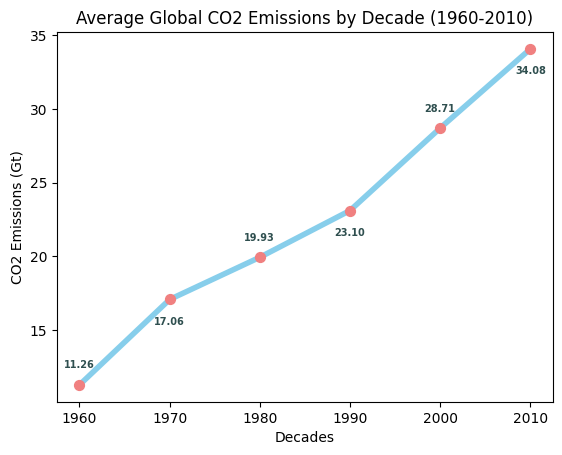

In [28]:
# Line chart for better Average Global CO2 Emissions by Decade (1960-2010)

lc= decade_df.plot(x= "Decade", y= "CO2 Emissions (Gt)", 
            color= "skyblue", linewidth=4, legend= False)
lc.scatter(decade_df['Decade'], decade_df['CO2 Emissions (Gt)'], 
           color= 'lightcoral', s=50, zorder=5)

# Adding data labels with better positioning
for i, row in decade_df.iterrows():
    # Alternate label position (above/below) to avoid crowding
    offset = 12 if i % 2 == 0 else -18
    
    lc.annotate(f"{row['CO2 Emissions (Gt)']:.2f}", 
                xy=(row['Decade'], row['CO2 Emissions (Gt)']),
                xytext=(0, offset), textcoords='offset points',
                ha='center', fontsize=7, color='darkslategrey',
                fontweight='bold')

plt.title("Average Global CO2 Emissions by Decade (1960-2010)")
plt.xlabel("Decades")
plt.ylabel("CO2 Emissions (Gt)")

In [29]:
# Pie chart for Regional share of Global Emissions.

# Accessing the Regional Emissions in 2011.

ge11= dataf.loc[dataf['Country Name']== 'World', '2011'].values[0]/1000
ge11

are_df= agg_df[["Region", "2011 (Mt)"]]
are_df["Regional Share"]= (are_df["2011 (Mt)"]/ge11)*100
ge11
are_df

,Region,2011 (Mt),Regional Share
1,East Asia & Pacific,10486.42,30.26
2,South Asia,2328.35,6.72
3,Middle East & North Africa,1309.43,3.78
4,Sub-Saharan Africa,738.90,2.13
5,Latin America & Caribbean,1210.41,3.49
6,Europe & Central Asia,1400.69,4.04
7,North America,5791.43,16.71
